In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import copy

In [19]:
cd 'joined_exposure_seagrass_datasets/GBR'

[Errno 2] No such file or directory: 'joined_exposure_seagrass_datasets/GBR'
/home/jovyan/dea_intertidal/dea-intertidal/notebooks/experimental/joined_exposure_seagrass_datasets/GBR


In [20]:
''' 
For TS_GOC_JCU_NESP_MaC-1-13_Seagrass-sites datasets
In QGIS: Read in geojson file of the exposure raster, reduce to points(Raster Pixels to Points).
Buffer the matching year seagrass observations to 6m (12 m diameter) to ensure overlap 
with one or more adjacent exposure values.
Join the seagrass observations to the exposure point data (Join Attributes by Location).
Export as geojson file and upload into dea_intertidal/dea-intertidal/notebooks/experimental/joined_exposure_seagrass_datasets
'''
files = glob.glob("x*.geojson")

ds = gpd.GeoDataFrame(pd.concat([gpd.read_file(file) for file in files], ignore_index=True))

ds

,FID_,MONTH,YEAR,SURVEY_NAM,LATITUTDE,LONGITUDE,PRESENCE_A,C_ROTUNDAT,C_SERRULAT,E_ACOROIDE,...,S_ISOETIFO,T_CILIATUM,T_HEMPRICH,Z_CAPRICOR,SEDIMENT,SURVEY_MET,TIDAL,DEPTH,VALUE,geometry
0,49401,September,2016,Townsville,-19.18044,146.73198,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,54.0,"MULTIPOLYGON (((1541685.488 -2142022.494, 1541..."
1,49410,September,2016,Townsville,-19.18160,146.72776,Absent,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,92.0,"MULTIPOLYGON (((1541231.018 -2142099.492, 1541..."
2,49410,September,2016,Townsville,-19.18160,146.72776,Absent,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,95.0,"MULTIPOLYGON (((1541231.018 -2142099.492, 1541..."
3,49446,September,2016,Townsville,-19.17889,146.73756,Present,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,38.0,"MULTIPOLYGON (((1542286.640 -2141918.925, 1542..."
4,49447,September,2016,Townsville,-19.18077,146.72544,Absent,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,47.0,"MULTIPOLYGON (((1540999.909 -2141979.980, 1540..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4258,30279,November,2018,Gladstone,-23.85990,151.32154,Absent,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,50.0,"MULTIPOLYGON (((1940124.413 -2721877.321, 1940..."
4259,30280,November,2018,Gladstone,-23.86128,151.32421,Absent,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,50.0,"MULTIPOLYGON (((1940367.192 -2722070.567, 1940..."
4260,30416,November,2018,Gladstone,-23.86139,151.31957,Absent,No,No,No,...,No,No,No,No,Mud,Helicopter,intertidal,0,49.0,"MULTIPOLYGON (((1939902.988 -2722012.274, 1939..."
4261,30420,November,2018,Gladstone,-23.86426,151.31922,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,54.0,"MULTIPOLYGON (((1939819.721 -2722324.525, 1939..."


In [21]:
ds['YEAR'].unique()

array([2016, 2018, 2017])

In [22]:
ds.columns

Index(['FID_', 'MONTH', 'YEAR', 'SURVEY_NAM', 'LATITUTDE', 'LONGITUDE',
       'PRESENCE_A', 'C_ROTUNDAT', 'C_SERRULAT', 'E_ACOROIDE', 'H_CAPRICOR',
       'H_DECIPIEN', 'H_OVALIS', 'H_SPINULOS', 'H_TRICOSTA', 'H_UNINERVI',
       'S_ISOETIFO', 'T_CILIATUM', 'T_HEMPRICH', 'Z_CAPRICOR', 'SEDIMENT',
       'SURVEY_MET', 'TIDAL', 'DEPTH', 'VALUE', 'geometry'],
      dtype='object')

In [23]:
# Remove rows where seagrass is absent
ds = ds[ds['PRESENCE_A'] != 'Absent']


In [24]:
ds

,FID_,MONTH,YEAR,SURVEY_NAM,LATITUTDE,LONGITUDE,PRESENCE_A,C_ROTUNDAT,C_SERRULAT,E_ACOROIDE,...,S_ISOETIFO,T_CILIATUM,T_HEMPRICH,Z_CAPRICOR,SEDIMENT,SURVEY_MET,TIDAL,DEPTH,VALUE,geometry
0,49401,September,2016,Townsville,-19.18044,146.73198,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,54.0,"MULTIPOLYGON (((1541685.488 -2142022.494, 1541..."
3,49446,September,2016,Townsville,-19.17889,146.73756,Present,No,No,No,...,No,No,No,No,Sand,Helicopter,intertidal,0,38.0,"MULTIPOLYGON (((1542286.640 -2141918.925, 1542..."
7,49449,September,2016,Townsville,-19.17860,146.73891,Present,No,No,No,...,No,No,No,Yes,Sand,Helicopter,intertidal,0,43.0,"MULTIPOLYGON (((1542430.995 -2141903.244, 1542..."
12,49521,September,2016,Townsville,-19.19059,146.71099,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,46.0,"MULTIPOLYGON (((1539369.183 -2142888.661, 1539..."
13,49617,September,2016,Townsville,-19.17655,146.73499,Present,No,No,No,...,No,No,No,No,Mud,Helicopter,intertidal,0,18.0,"MULTIPOLYGON (((1542048.777 -2141629.871, 1542..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255,30276,November,2018,Gladstone,-23.85672,151.31896,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,42.0,"MULTIPOLYGON (((1939920.945 -2721486.277, 1939..."
4256,30277,November,2018,Gladstone,-23.86827,151.32232,Present,No,No,No,...,No,No,No,Yes,Sand,Helicopter,intertidal,0,47.0,"MULTIPOLYGON (((1940060.985 -2722815.306, 1940..."
4257,30278,November,2018,Gladstone,-23.86534,151.32212,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,51.0,"MULTIPOLYGON (((1940090.469 -2722488.064, 1940..."
4261,30420,November,2018,Gladstone,-23.86426,151.31922,Present,No,No,No,...,No,No,No,Yes,Mud,Helicopter,intertidal,0,54.0,"MULTIPOLYGON (((1939819.721 -2722324.525, 1939..."


In [25]:
ds.columns

Index(['FID_', 'MONTH', 'YEAR', 'SURVEY_NAM', 'LATITUTDE', 'LONGITUDE',
       'PRESENCE_A', 'C_ROTUNDAT', 'C_SERRULAT', 'E_ACOROIDE', 'H_CAPRICOR',
       'H_DECIPIEN', 'H_OVALIS', 'H_SPINULOS', 'H_TRICOSTA', 'H_UNINERVI',
       'S_ISOETIFO', 'T_CILIATUM', 'T_HEMPRICH', 'Z_CAPRICOR', 'SEDIMENT',
       'SURVEY_MET', 'TIDAL', 'DEPTH', 'VALUE', 'geometry'],
      dtype='object')

In [26]:
# >>> d = {'a': 1, 'b': 2, 'c': 3}
# >>> ser = pd.Series(data=d, index=['a', 'b', 'c'])

CR = ds[['C_ROTUNDAT','VALUE']][ds['C_ROTUNDAT'] != 'No']
CS = ds[['C_SERRULAT','VALUE']][ds['C_SERRULAT'] != 'No']
EA = ds[['E_ACOROIDE','VALUE']][ds['E_ACOROIDE'] != 'No']
HC = ds[['H_CAPRICOR','VALUE']][ds['H_CAPRICOR'] != 'No']
HD = ds[['H_DECIPIEN','VALUE']][ds['H_DECIPIEN'] != 'No']
HO = ds[['H_OVALIS','VALUE']][ds['H_OVALIS'] != 'No']
HS = ds[['H_SPINULOS','VALUE']][ds['H_SPINULOS'] != 'No']
HT = ds[['H_TRICOSTA','VALUE']][ds['H_TRICOSTA'] != 'No']
HU = ds[['H_UNINERVI','VALUE']][ds['H_UNINERVI'] != 'No']
SI = ds[['S_ISOETIFO','VALUE']][ds['S_ISOETIFO'] != 'No']
TC = ds[['T_CILIATUM','VALUE']][ds['T_CILIATUM'] != 'No']
TH = ds[['T_HEMPRICH','VALUE']][ds['T_HEMPRICH'] != 'No']
ZC = ds[['Z_CAPRICOR','VALUE']][ds['Z_CAPRICOR'] != 'No']

data1 = {'Cymodocea\nrotundata' : list(CR['VALUE'].values),
        'Cymodocea\nserrulata' : list(CS['VALUE'].values),
        'Enhalus\nacoroides' : list(EA['VALUE'].values),
        'Halodule\nuninervis' : list(HU['VALUE'].values),
        'Halophila\ncapricorni' : list(HC['VALUE'].values),
        'Halophila\ndecipiens' : list(HD['VALUE'].values),
        'Halophila\novalis' : list(HO['VALUE'].values),
        'Halophila\nspinulosa' : list(HS['VALUE'].values),
        'Halophila\ntricostata' : list(HT['VALUE'].values),
        'Syringodium\nisoetifolium' : list(SI['VALUE'].values),
        'Thalassia\nhemprichii' : list(TH['VALUE'].values),
        'Thalassodendron\nciliatum' : list(TC['VALUE'].values),
        'Zostera\nmuelleri' : list(ZC['VALUE'].values)
       }

seagrass = pd.Series(data=data1, index=sorted(data1.keys()))

In [27]:
seagrass

Cymodocea\nrotundata                                                        []
Cymodocea\nserrulata         [21.0, 16.0, 12.0, 13.0, 15.0, 14.0, 17.0, 22....
Enhalus\nacoroides                                                      [18.0]
Halodule\nuninervis          [54.0, 38.0, 43.0, 46.0, 18.0, 20.0, 21.0, 22....
Halophila\ncapricorni                                                       []
Halophila\ndecipiens         [20.0, 36.0, 25.0, 23.0, 34.0, 36.0, 37.0, 39....
Halophila\novalis            [54.0, 46.0, 22.0, 23.0, 14.0, 17.0, 14.0, 22....
Halophila\nspinulosa                                              [47.0, 41.0]
Halophila\ntricostata                                                       []
Syringodium\nisoetifolium                                                   []
Thalassia\nhemprichii                                                       []
Thalassodendron\nciliatum                                                   []
Zostera\nmuelleri            [54.0, 43.0, 46.0, 21.0

In [28]:
# values_by_macrophyte = ds.groupby('Macrophyte_min')['VALUE'].apply(list)
# values_by_macrophyte

(0.0, 100.0)

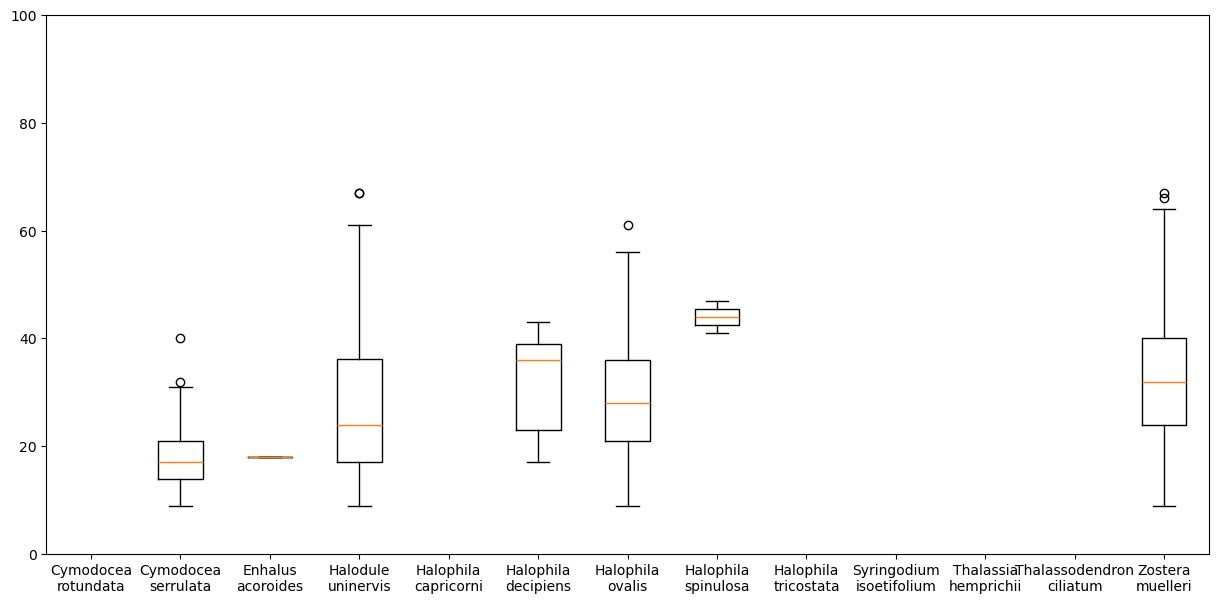

In [29]:
plt.figure(figsize=(15,7))
plt.boxplot(seagrass, tick_labels=seagrass.index)
plt.ylim(0,100)

In [30]:
# Drop empty arrays from the seagrass series

# Assuming `series` is your Pandas Series of arrays
# series = series[series.apply(lambda x: len(x) > 0)]

seagrass2 = seagrass[seagrass.apply(lambda x: len(x) > 0)]

Text(0.5, 1.0, 'Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)')

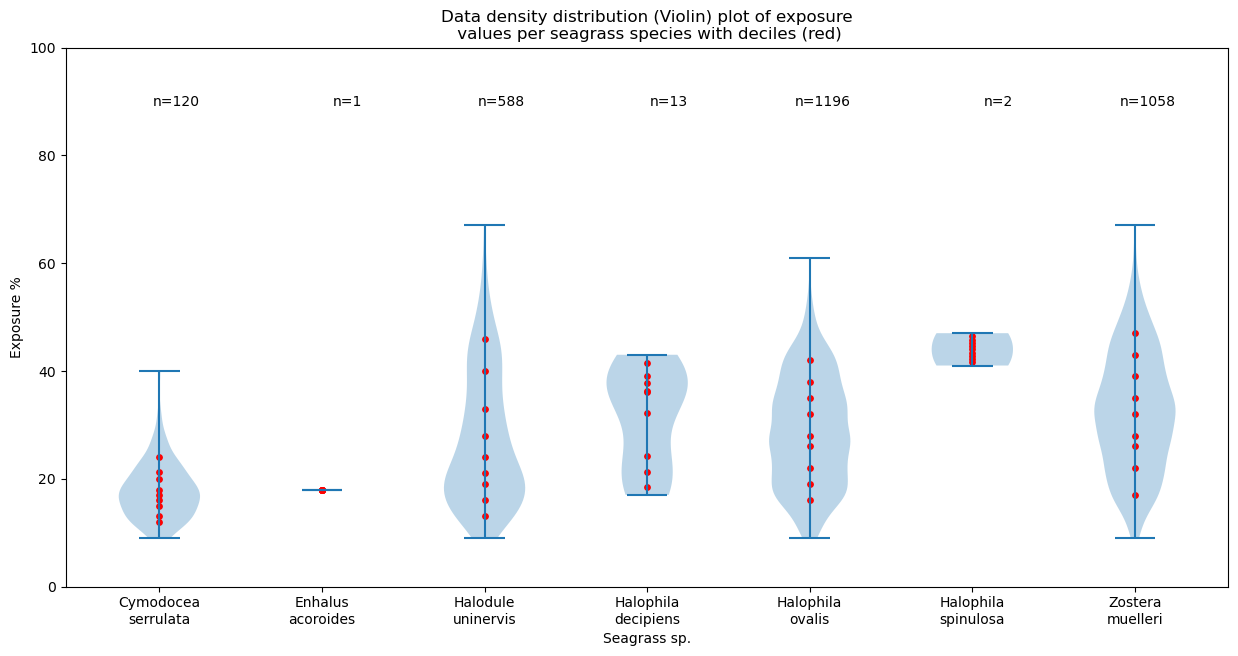

In [31]:
data = list(seagrass2)
deciles = [np.percentile(values, np.arange(10,100,10)) for values in data]
seagrass_counts = pd.Series(data = list(len(x) for x in seagrass2.array), index = seagrass2.index)

plt.figure(figsize=(15,7))
plt.violinplot(data)

for i, decile_values in enumerate(deciles, start=1):
    plt.scatter([i] * len(decile_values), decile_values, color='r', marker='o', s=15, label='Deciles' if i==1 else "")

for i, (name,count) in enumerate(seagrass_counts.items()):
    plt.text(i+1.25, 90, f'n={count}', ha='right', va = 'center', color='black',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.xticks(range(1,len(seagrass2) +1), seagrass2.index)
plt.ylim(0,100)

plt.xlabel("Seagrass sp.")
plt.ylabel("Exposure %")
plt.title("Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)")

In [32]:
data_GBR = copy.deepcopy(seagrass)

In [33]:
%store data_GBR

Stored 'data_GBR' (Series)


In [34]:
type(seagrass)

pandas.core.series.Series